In [31]:
# Task 1: Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
# Task 2: Load the Amazon reviews dataset

df = pd.read_csv("amazonreviews.tsv", sep="\t")

print(df.head())

  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...


In [33]:
# Task 3: Display dataset information and structure

print(df.info())

print(df.shape)

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None
(10000, 2)
  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...


In [34]:
# Task 4: Identify missing values in the dataset

print(df.isnull().sum())

label     0
review    0
dtype: int64


In [35]:
# Task 5: Remove duplicate and missing records

df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

print(df.shape)


(10000, 2)


In [36]:
# Task 6: Clean review text using preprocessing techniques

import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

print(df[['review','clean_review']].head())

                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After He...   

                                        clean_review  
0  stuning even nongamer sound track beautiful pa...  
1  best soundtrack ever anything im reading lot r...  
2  amazing soundtrack favorite music time hands i...  
3  excellent soundtrack truly like soundtrack enj...  
4  remember pull jaw floor hearing youve played g...  


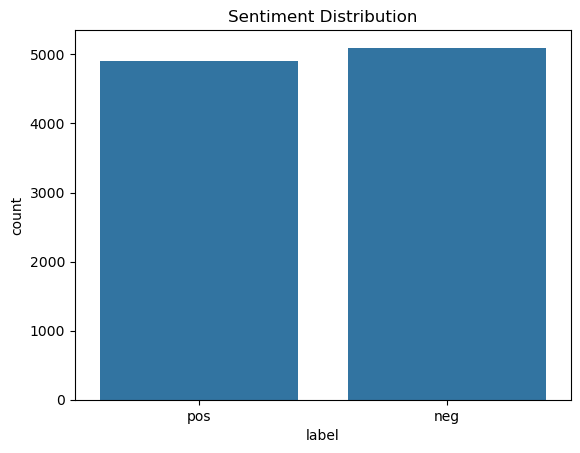

In [37]:
# Task 7: Visualize sentiment distribution

sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")

plt.show()

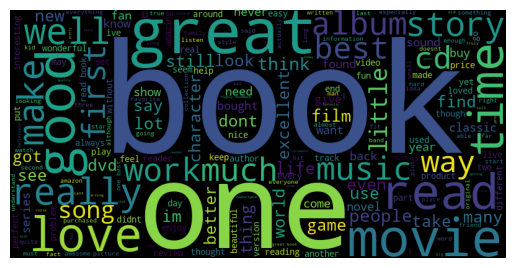

In [38]:
# Task 8: Generate word cloud for positive reviews

from wordcloud import WordCloud

positive_text = " ".join(
    df[df['label']=='pos']['clean_review']
)

wc = WordCloud(width=800,height=400).generate(positive_text)

plt.imshow(wc)

plt.axis('off')

plt.show()

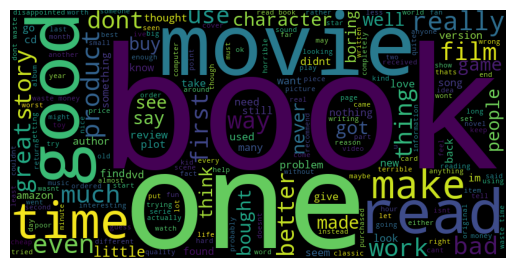

In [39]:
# Task 9: Generate word cloud for negative reviews

negative_text = " ".join(
    df[df['label']=='neg']['clean_review']
)

wc = WordCloud(width=800,height=400).generate(negative_text)

plt.imshow(wc)

plt.axis('off')

plt.show()

In [40]:
# Task 10: Display most common positive words

from collections import Counter

positive_words = " ".join(
    df[df['label']=='pos']['clean_review']
).split()

print(Counter(positive_words).most_common(20))

[('book', 3313), ('great', 2087), ('one', 1835), ('good', 1635), ('read', 1553), ('like', 1268), ('movie', 1085), ('would', 943), ('love', 902), ('time', 871), ('well', 854), ('really', 827), ('best', 801), ('get', 793), ('story', 713), ('first', 708), ('much', 650), ('cd', 581), ('music', 559), ('also', 557)]


In [41]:
# Task 11: Display most common negative words

negative_words = " ".join(
    df[df['label']=='neg']['clean_review']
).split()

print(Counter(negative_words).most_common(20))

[('book', 3184), ('one', 2022), ('like', 1547), ('movie', 1465), ('would', 1438), ('dont', 1240), ('read', 1187), ('get', 1139), ('good', 1134), ('time', 1034), ('even', 898), ('buy', 814), ('really', 778), ('much', 769), ('bad', 749), ('money', 744), ('first', 736), ('could', 658), ('better', 656), ('great', 632)]


In [42]:
# Task 12: Convert sentiment labels into numerical values

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

print(df['label'].value_counts())

label
0    5097
1    4903
Name: count, dtype: int64


In [43]:
# Task 13: Convert review text into TF-IDF features

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

y = df['label']

In [44]:
# Task 14: Split dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [45]:
# Task 15: Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [46]:
# Task 16: Evaluate Logistic Regression performance

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy:",accuracy_score(y_test,lr_pred))

print(classification_report(y_test,lr_pred))

Accuracy: 0.845
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1037
           1       0.83      0.85      0.84       963

    accuracy                           0.84      2000
   macro avg       0.84      0.85      0.84      2000
weighted avg       0.85      0.84      0.85      2000



In [47]:
# Task 17: Train Support Vector Machine model

from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

In [48]:
# Task 18: Evaluate Support Vector Machine performance

print("Accuracy:",accuracy_score(y_test,svm_pred))

print(classification_report(y_test,svm_pred))

Accuracy: 0.8355
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1037
           1       0.83      0.83      0.83       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [49]:
# Task 19: Perform cross validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    svm,
    X,
    y,
    cv=5
)

print(scores)

print("Mean Accuracy:",scores.mean())

[0.8445 0.8125 0.8195 0.82   0.845 ]
Mean Accuracy: 0.8282999999999999


In [50]:
# Task 20: Compare model performance

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "SVM"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,svm_pred)
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression    0.8450
1                  SVM    0.8355


In [51]:
# Task 21: Summarize important findings

print("Positive reviews contain appreciation words.")

print("Negative reviews contain complaint words.")

print("TF-IDF successfully converted text into numerical features.")

print("SVM performs effectively for sentiment classification.")

Positive reviews contain appreciation words.
Negative reviews contain complaint words.
TF-IDF successfully converted text into numerical features.
SVM performs effectively for sentiment classification.


In [52]:
# Task 22: Display final conclusion

print("Sentiment analysis system developed successfully.")

print("Text preprocessing improved data quality.")

print("TF-IDF extracted meaningful features.")

print("Machine learning models classified reviews accurately.")

print("The solution can support automated customer feedback analysis.")

Sentiment analysis system developed successfully.
Text preprocessing improved data quality.
TF-IDF extracted meaningful features.
Machine learning models classified reviews accurately.
The solution can support automated customer feedback analysis.
